In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/1st_test")
files = sorted([f for f in DATA_DIR.iterdir() if f.is_file() and not f.name.startswith('.')])

cols = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8"]
healthy = pd.read_csv(files[0], sep='\t', header=None, names=cols)
broken = pd.read_csv(files[-1], sep='\t', header=None, names=cols)

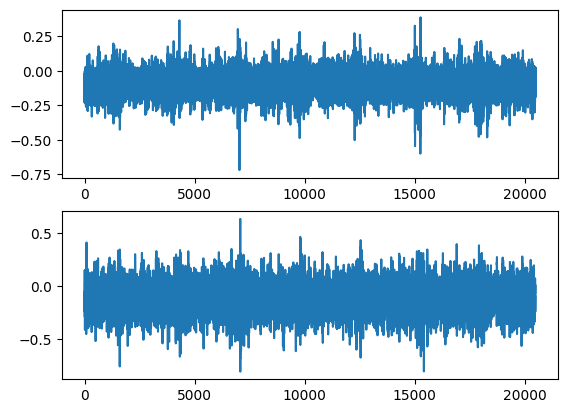

In [3]:
fig, axs = plt.subplots(2)
axs[0].plot(healthy['B1'])
axs[1].plot(broken['B1'])

44


[]

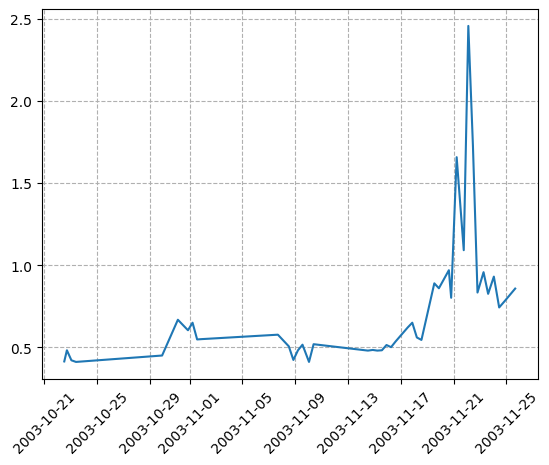

In [6]:
timestamps = []
values = []
sampled_files = files[::50]
for file in sampled_files:
    column_0 = pd.read_csv(file, sep='\t', header=None, names=cols)["B7"].abs().max()
    timestamps.append(pd.to_datetime(file.name, format="%Y.%m.%d.%H.%M.%S"))
    values.append(column_0)

df = pd.DataFrame({"timestamps": timestamps, "value": values})
print(len(values))
plt.plot(df["timestamps"], df["value"])
plt.xticks(rotation=45)
plt.grid(True, linestyle='--')
plt.plot()